# Stage 1 — Explore

**Goal:** understand the data before touching a model. By the end of this notebook I should be able to answer: which features actually predict conversion, and what traps are hiding in this dataset?

**Business framing:** each row is a prospect a bank called. `y` = did they convert. This is lead scoring — same problem I want to solve for JustAutomateX, on someone else's funnel until mine has volume.

**Rule for this notebook:** I write the analysis. Claude gives the questions, not the answers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

df = pd.read_csv('data/bank-additional/bank-additional-full.csv', sep=';')
print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


---
## Q1 — What am I working with?

Find out:
- how many rows and columns
- which columns are numeric vs categorical
- the target balance: how many `yes` vs `no`, and the conversion rate as a percentage

**Then answer in the markdown cell below:** if I built a model that predicted `no` for every single prospect, what accuracy would it get? What does that tell me about using accuracy as my metric?

In [2]:
# TODO: shape, dtypes, target balance, conversion rate

rows, cols = df.shape
print(rows, cols)


typ = (df.dtypes)
print(typ)


target_counts = df['y'].value_counts()
print(target_counts)


Yes = (df['y'] == 'yes').sum()
No = (df['y'] == 'no').sum()
total = len(df)

print(total)

conversion = (Yes/total)*100
print(conversion)

41188 21
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object
y
no     36548
yes     4640
Name: count, dtype: int64
41188
11.265417111780131


"The accuracy would not be 100%, as when you get complete NO's, thats 36548 out of 41188. 
"And remaining would be left out like that."

In [3]:
Accuracy_of_no = (No/total)*100
print(Accuracy_of_no)

88.73458288821988


"And this isn't the actual metric to take on when the classes are completely inbalance."

---
## Q2 — Which categorical features move conversion?

For each categorical column, compute the **conversion rate per category** — not the raw count. A category with 3 leads and 2 conversions is 67%, but it's noise; always look at the count alongside the rate.

Hint: `df.groupby(col)['y'].value_counts(normalize=True)` gets you partway, but it's cleaner to make a boolean target first:
```python
df['converted'] = (df['y'] == 'yes').astype(int)
df.groupby(col)['converted'].agg(['mean', 'count'])
```

Do this for `job`, `education`, `contact`, `month`, `poutcome`, `default`.

**Then answer:** which three categories have the strongest signal, and does the direction make business sense?

In [11]:
# TODO: conversion rate + count per category, for each categorical column
# Create binary target (1 = converted, 0 = not converted)
df['converted'] = (df['y'] == 'yes').astype(int)
categorical_cols = [
    'job',
    'education',
    'contact',
    'month',
    'poutcome',
    'default'
]
for col in categorical_cols:
    print("=" * 60)
    print(f"\n{col.upper()}\n")

    result = (
        df.groupby(col)['converted']
          .agg(
              Conversion_Rate=('mean'),
              Total_Leads=('count')
          )
    )

    result['Conversion_Rate'] = (result['Conversion_Rate'] * 100).round(2)

    print(result.sort_values(by='Conversion_Rate', ascending=False))


JOB

               Conversion_Rate  Total_Leads
job                                        
student                  31.43          875
retired                  25.23         1720
unemployed               14.20         1014
admin.                   12.97        10422
management               11.22         2924
unknown                  11.21          330
technician               10.83         6743
self-employed            10.49         1421
housemaid                10.00         1060
entrepreneur              8.52         1456
services                  8.14         3969
blue-collar               6.89         9254

EDUCATION

                     Conversion_Rate  Total_Leads
education                                        
illiterate                     22.22           18
unknown                        14.50         1731
university.degree              13.72        12168
professional.course            11.35         5243
high.school                    10.84         9515
basic.4y        

**My answer:**

Among these features, from each one, there's specifc values whose conversion rate is high.
And those are, from JOb - student(875) and retired(1720), Month - march, Poutcome - success.
When it comes to the poutcome, the one who have succeded are the ones coming agian and Among all the features, their conversion rate is high.
In the feature of job - studends and the retired one's have been converted more.
And at the same time, in the month of march ande december, the conversion rate is so high 

---
## Q3 — What do the numeric features look like?

Compare the distribution of each numeric feature for converted vs not-converted. Two ways, do both:

1. `df.groupby('converted')[numeric_cols].mean()` — quick numeric comparison
2. A histogram or boxplot for two or three of the more interesting ones

Pay attention to the scale of each column — `nr.employed` is around 5000, `emp.var.rate` is around 0. **Which week's lesson does that trigger?**

In [9]:
# TODO: numeric distributions split by converted
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('converted')
df.groupby('converted')[numeric_cols].mean()



,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
converted,,,,,,,,,,
0,39.911185,220.844807,2.633085,984.113878,0.132374,0.248875,93.603757,-40.593097,3.811491,5176.166600
1,40.913147,553.191164,2.051724,792.035560,0.492672,-1.233448,93.354386,-39.789784,2.123135,5095.115991


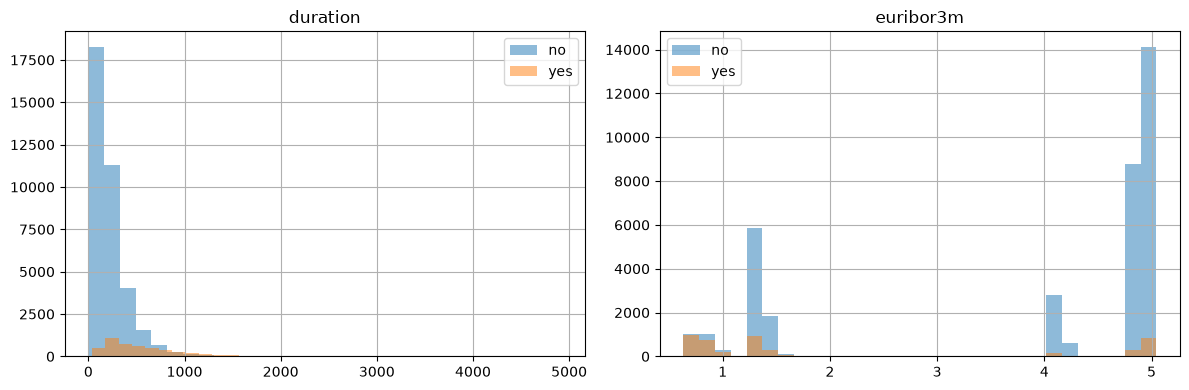

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['duration', 'euribor3m']):
    df[df['converted']==0][col].hist(ax=ax, alpha=0.5, label='no', bins=30)
    df[df['converted']==1][col].hist(ax=ax, alpha=0.5, label='yes', bins=30)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

**My answer:**

The values of the features are varying a lot, It makes the gradient descent slow convergeing and sometimes not converges. So we use feture scalling to sort out these kind of issues.

---
## Q4 — The `duration` trap

`duration` is the length of the call in seconds.

1. Compute the mean `duration` for converted vs not-converted. The gap is huge.
2. Now think about **when** that number becomes known.

**Answer these:** if I'm scoring a lead to decide whether to call them, do I know `duration` yet? What happens to my model's real-world usefulness if I train on it? What should I do with this column, and why?

This is the single most important judgement call in this project — the writeup will live or die on whether I explain it correctly.

In [14]:
# Mean duration and count by outcome
duration_summary = (
    df.groupby('y')
      .agg(
          Mean_Duration=('duration', 'mean'),
          Total_Leads=('duration', 'count')
      )
      .round(2)
)

print(duration_summary)

     Mean_Duration  Total_Leads
y                              
no          220.84        36548
yes         553.19         4640


**My answer:**

We cannot determine the duration, it is the information from the future, can only have after having the call.
Considering this feature for the model is devastating, As the duration varies for each lead call and when the model tries to find out the duration of a particular lead, whom we have not called, then it could go completely wrong and does not give the actual values.
We should drop this feature 


---
## Q5 — The `pdays` sentinel

`pdays` = days since the client was last contacted in a previous campaign.

1. Look at `df['pdays'].value_counts().head()` and `df['pdays'].describe()`.
2. One value dominates. What is it, and how many rows have it?

**Answer:** what does that value actually mean (check `data/bank-additional/bank-additional-names.txt`)? Why is leaving it as a raw number a problem for a linear model? Propose a fix.

Same question, smaller stakes, for the `unknown` values in `default` (21% of rows), `education`, `job`.

In [ ]:
# TODO: pdays distribution, unknown counts
print(df['pdays'].value_counts().head())
print(df['pdays'].describe())

In [17]:
# Binary feature: Was the client contacted before?
df['was_contacted_before'] = (df['pdays'] < 999).astype(int)

# Keep the actual number of days only for previously contacted clients
df['pdays_actual'] = df['pdays'].where(df['pdays'] < 999, 0)

df[['pdays', 'was_contacted_before', 'pdays_actual']].head()

,pdays,was_contacted_before,pdays_actual
0,999,0,0
1,999,0,0
2,999,0,0
3,999,0,0
4,999,0,0


**My answer:**

The value 999 dominates the pdays column, appearing in 39,673 of 41,188 rows. According to the dataset documentation, 999 is a sentinel value that means the client was not previously contacted, not that they were contacted 999 days ago.Treating it as a normal numeric value is misleading, especially for a linear model, because the model will interpret 999 as an extremely large number of days rather than a separate category.
So, we'll just take it in this way, if value is less than 999 then we consider as 1 

## Findings — write this last

- **Dataset:** The dataset contains information collected from a Portuguese bank's direct marketing campaigns. The goal is to predict whether a customer will subscribe to a term deposit (y = yes/no).
- **Target and balance:** The target variable is y, which indicates whether the customer subscribed to a term deposit. The dataset is imbalanced, with many more "No" responses than "Yes" responses, so accuracy alone is not a reliable evaluation metric
- **Strongest predictors:** Features such as poutcome, Month, and Job show strong relationships with the target.
- **Features I'm dropping and why:** Duration should not be used because it is only known after the call has ended, causing data leakage.
- **Features needing transformation:** Transform the pdays feature by creating a binary feature (was_contacted_before) because the value 999 means "client was never contacted before", not "999 days ago."
- **Metric I'll use instead of accuracy, and why:** will use Precision, Recall, F1-score, and ROC-AUC instead of relying only on accuracy because the dataset is imbalanced. A model predicting mostly "No" could achieve high accuracy while failing to identify customers who actually subscribe.
- **Open questions:** 1. Which features contribute the most after removing duration? 2. Should unknown values be treated as a separate category or imputed?